In [19]:
# Import the libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
import sqlite3


# Step 1: Collect API Data


In [2]:

# Define the direct API endpoint URL with query parameters
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

# Send a GET request to the specified URL
response = requests.get(url)

# Parse and store the API response directly as raw JSON
data = response.json()

# Step 2: Create the Dataset


In [7]:
# Create DataFrame from the repository list inside items key
df = pd.DataFrame(data['items'])

# Preview the DataFrame structure and contents
print(df.head())

# Display column names and data types
print(df.info())

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


# Step 3: Select Required Columns


In [8]:
# Define the list of selected required columns
selected_columns = ['name', 'owner', 'language', 'stargazers_count', 'forks_count', 'watchers_count', 'open_issues_count', 'created_at', 'updated_at', 'license']

# Filter the DataFrame to keep only the selected columns
df = df[selected_columns]

# Preview the filtered DataFrame
print(df.head())

                       name  \
0                tensorflow   
1              transformers   
2          ML-For-Beginners   
3                    funNLP   
4  awesome-machine-learning   

                                               owner          language  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...               C++   
1  {'login': 'huggingface', 'id': 25720743, 'node...            Python   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...  Jupyter Notebook   
3  {'login': 'fighting41love', 'id': 11475294, 'n...            Python   
4  {'login': 'josephmisiti', 'id': 246302, 'node_...            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            196988        76044          196988               2918   
1            164193        34258          164193               2386   
2             89459        21956           89459                 11   
3             82513        15267           82513                 53   
4            

# Step 4: Extract Required Values


In [9]:
# Function to get owner login name
def get_owner_name(owner_dict):
    if owner_dict is not None:
        return owner_dict['login']
    return None

# Function to get license spdx id
def get_license_name(license_dict):
    if license_dict is not None:
        return license_dict['spdx_id']
    return None

# Extract owner name using the simple function
df['owner'] = df['owner'].apply(get_owner_name)

# Extract license name using the simple function
df['license'] = df['license'].apply(get_license_name)

# Preview the DataFrame
print(df.head())

                       name           owner          language  \
0                tensorflow      tensorflow               C++   
1              transformers     huggingface            Python   
2          ML-For-Beginners       microsoft  Jupyter Notebook   
3                    funNLP  fighting41love            Python   
4  awesome-machine-learning    josephmisiti            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            196988        76044          196988               2918   
1            164193        34258          164193               2386   
2             89459        21956           89459                 11   
3             82513        15267           82513                 53   
4             74042        15608           74042                 24   

             created_at            updated_at      license  
0  2015-11-07T01:19:20Z  2026-08-17T21:06:38Z   Apache-2.0  
1  2018-10-29T13:56:00Z  2026-08-17T21:00:08Z   Apache-2.0  

# Step 5: Handle Missing Values


In [10]:
# Check total missing values in each column
print(df.isnull().sum())

# Fill missing values in language and license columns with 'Unknown'
df['language'] = df['language'].fillna('Unknown')
df['license'] = df['license'].fillna('Unknown')

# Preview the cleaned DataFrame
print(df.head())

name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64
                       name           owner          language  \
0                tensorflow      tensorflow               C++   
1              transformers     huggingface            Python   
2          ML-For-Beginners       microsoft  Jupyter Notebook   
3                    funNLP  fighting41love            Python   
4  awesome-machine-learning    josephmisiti            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            196988        76044          196988               2918   
1            164193        34258          164193               2386   
2             89459        21956           89459                 11   
3             82513        15267           82513                 53   
4

# Step 6: Handle Duplicate Records


In [11]:
# Check total count of duplicate rows in the DataFrame
print(df.duplicated().sum())

# Remove duplicate rows from the DataFrame
df = df.drop_duplicates()

# Preview the DataFrame after removing duplicates
print(df.head())

0
                       name           owner          language  \
0                tensorflow      tensorflow               C++   
1              transformers     huggingface            Python   
2          ML-For-Beginners       microsoft  Jupyter Notebook   
3                    funNLP  fighting41love            Python   
4  awesome-machine-learning    josephmisiti            Python   

   stargazers_count  forks_count  watchers_count  open_issues_count  \
0            196988        76044          196988               2918   
1            164193        34258          164193               2386   
2             89459        21956           89459                 11   
3             82513        15267           82513                 53   
4             74042        15608           74042                 24   

             created_at            updated_at      license  
0  2015-11-07T01:19:20Z  2026-08-17T21:06:38Z   Apache-2.0  
1  2018-10-29T13:56:00Z  2026-08-17T21:00:08Z   Apache-2.0

# Step 7: Prepare the Dataset


In [12]:
# Convert date columns to standard datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

# Rename specified columns for clarity and easier SQL usage
df = df.rename(columns={
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
})

# Preview the DataFrame with updated column names and formats
print(df.head())

                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  196988  76044   
1              transformers     huggingface            Python  164193  34258   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89459  21956   
3                    funNLP  fighting41love            Python   82513  15267   
4  awesome-machine-learning    josephmisiti            Python   74042  15608   

   watchers  open_issues              created_date              updated_date  \
0    196988         2918 2015-11-07 01:19:20+00:00 2026-08-17 21:06:38+00:00   
1    164193         2386 2018-10-29 13:56:00+00:00 2026-08-17 21:00:08+00:00   
2     89459           11 2021-03-03 01:34:05+00:00 2026-08-17 22:23:13+00:00   
3     82513           53 2018-08-21 11:20:39+00:00 2026-08-17 18:29:06+00:00   
4     74042           24 2014-07-15 19:11:19+00:00 2026-08-17 20:17:22+00:00   

       license  
0   Apache-2.0  
1   

# Step 8: Save and Verify the Dataset


In [13]:
# Save the prepared DataFrame to a CSV file
df.to_csv('github_projects.csv', index=False)

# Reload the saved CSV file to verify its contents
df_reloaded = pd.read_csv('github_projects.csv')

# Display dataset summary to confirm correct structure and row counts
print(df_reloaded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner         100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license       100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB
None


# Step 9: Create the SQLite Database


In [20]:
# Load the prepared CSV file into a pandas DataFrame
df = pd.read_csv('github_projects.csv')

# Create a connection to the SQLite database file
conn = sqlite3.connect('github_projects.db')

# Import the DataFrame into the SQLite database as the 'Repositories' table
df.to_sql('Repositories', conn, if_exists='replace', index=False)


100

# Step 10: Filtering & Searching Queries

In [21]:
# Query 1: Filter repositories with more than 10,000 stars
query_stars = "SELECT * FROM Repositories WHERE stars > 10000"
df_stars = pd.read_sql_query(query_stars, conn)

# Query 2: Find repositories whose names contain the word 'Machine'
query_machine = "SELECT * FROM Repositories WHERE name LIKE '%Machine%'"
df_machine = pd.read_sql_query(query_machine, conn)

# Display results for both queries
print("Repositories with > 10,000 stars:")
print(df_stars.head())

print("\nRepositories containing 'Machine' in name:")
print(df_machine.head())


Repositories with > 10,000 stars:
                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  196988  76044   
1              transformers     huggingface            Python  164193  34258   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89459  21956   
3                    funNLP  fighting41love            Python   82513  15267   
4  awesome-machine-learning    josephmisiti            Python   74042  15608   

   watchers  open_issues               created_date  \
0    196988         2918  2015-11-07 01:19:20+00:00   
1    164193         2386  2018-10-29 13:56:00+00:00   
2     89459           11  2021-03-03 01:34:05+00:00   
3     82513           53  2018-08-21 11:20:39+00:00   
4     74042           24  2014-07-15 19:11:19+00:00   

                updated_date      license  
0  2026-08-17 21:06:38+00:00   Apache-2.0  
1  2026-08-17 21:00:08+00:00   Apache-2.0  
2  2026-08-17 22:23:13

# Step 11: Logical Operators

In [22]:
# Query 1: Use AND along with NOT to find Python repos with over 5,000 stars that are not licensed under MIT
query_1 = "SELECT * FROM Repositories WHERE language = 'Python' AND stars > 5000 AND NOT license = 'MIT'"
df_query_1 = pd.read_sql_query(query_1, conn)

# Query 2: Use OR along with AND to find popular repos (stars > 20000) or heavily forked Python repos
query_2 = "SELECT * FROM Repositories WHERE stars > 20000 OR (language = 'Python' AND forks > 5000)"
df_query_2 = pd.read_sql_query(query_2, conn)

# Display results for both queries
print("Query 1 (AND, NOT):")
print(df_query_1.head())

print("\nQuery 2 (OR, AND):")
print(df_query_2.head())


Query 1 (AND, NOT):
                       name           owner language   stars  forks  watchers  \
0              transformers     huggingface   Python  164193  34258    164193   
1                    funNLP  fighting41love   Python   82513  15267     82513   
2  awesome-machine-learning    josephmisiti   Python   74042  15608     74042   
3              scikit-learn    scikit-learn   Python   66965  27291     66965   
4                    gradio      gradio-app   Python   43376   3575     43376   

   open_issues               created_date               updated_date  \
0         2386  2018-10-29 13:56:00+00:00  2026-08-17 21:00:08+00:00   
1           53  2018-08-21 11:20:39+00:00  2026-08-17 18:29:06+00:00   
2           24  2014-07-15 19:11:19+00:00  2026-08-17 20:17:22+00:00   
3         2126  2010-08-17 09:43:38+00:00  2026-08-17 21:51:10+00:00   
4          182  2018-12-19 08:24:04+00:00  2026-08-17 22:08:26+00:00   

        license  
0    Apache-2.0  
1       Unknown  
2   NO

# Step 12: Sorting & Limiting Queries


In [18]:


# Write SQL query to select Top 10 repositories ordered by stars descending
query_top10 = "SELECT * FROM Repositories ORDER BY stars DESC LIMIT 10"

# Execute query and load results into a pandas DataFrame
df_top10 = pd.read_sql_query(query_top10, conn)

# Display the Top 10 most popular repositories
print(df_top10)


                                                name           owner  \
0                                         tensorflow      tensorflow   
1                                       transformers     huggingface   
2                                   ML-For-Beginners       microsoft   
3                                             funNLP  fighting41love   
4                           awesome-machine-learning    josephmisiti   
5                                       scikit-learn    scikit-learn   
6                                             gradio      gradio-app   
7  500-AI-Machine-learning-Deep-learning-Computer...   ashishpatel26   
8                                        C-Plus-Plus   TheAlgorithms   
9                                             netron      lutzroeder   

           language   stars  forks  watchers  open_issues  \
0               C++  196988  76044    196988         2918   
1            Python  164193  34258    164193         2386   
2  Jupyter Notebook   89

# Step 13: Aggregate Functions






In [23]:
# Write SQL query to calculate total count and average stars
query_summary = "SELECT COUNT(*) AS total_repositories, AVG(stars) AS average_stars FROM Repositories"

# Execute query and load summary data into a DataFrame
df_summary = pd.read_sql_query(query_summary, conn)

# Display the summary results
print(df_summary)

   total_repositories  average_stars
0                 100       20799.25


# Step 14: Grouping Analysis


In [24]:
# Write SQL query to group by language and filter groups with more than 5 repositories
query_group = """
SELECT language, COUNT(*) AS total_repositories
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY total_repositories DESC
"""

# Execute query and load grouped results into a DataFrame
df_grouped = pd.read_sql_query(query_group, conn)

# Display the grouped results
print(df_grouped)

           language  total_repositories
0            Python                  30
1           Unknown                  23
2  Jupyter Notebook                  19
3               C++                  12


# Step 15: Create Python Visualizations


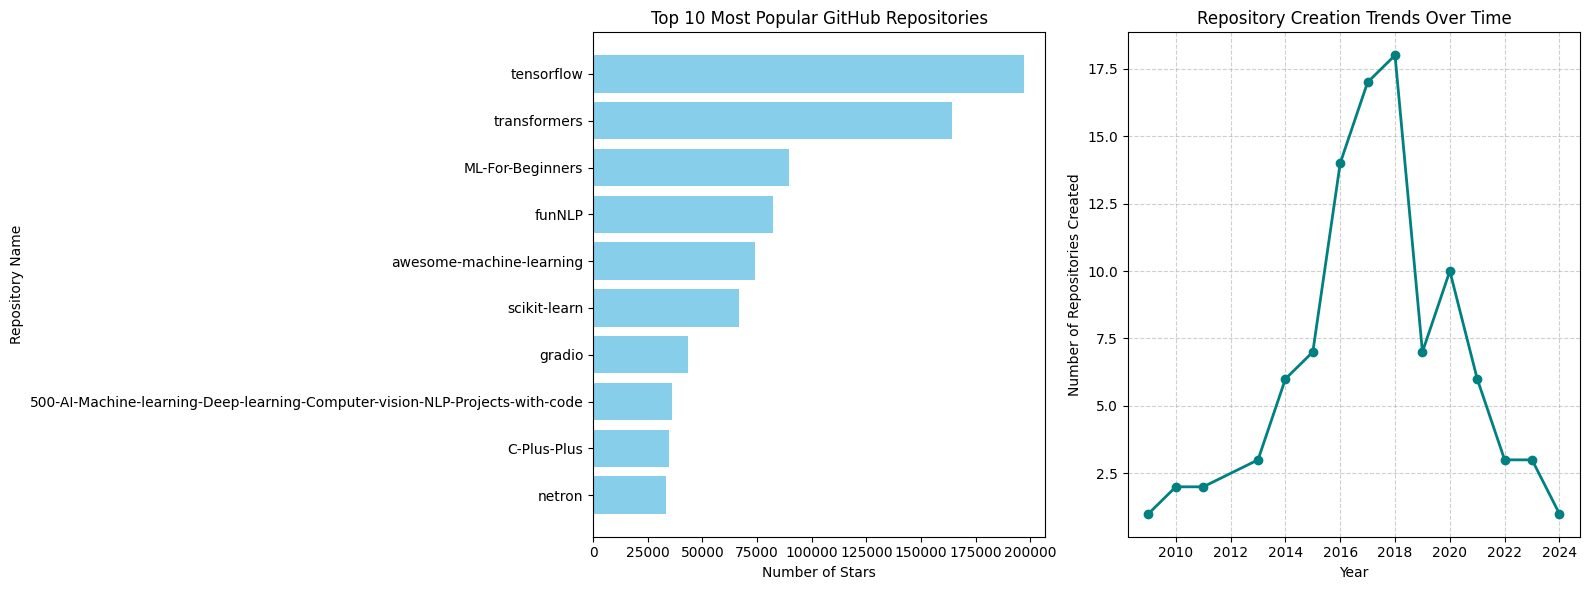

In [40]:

# Connect to the SQLite database
conn = sqlite3.connect('github_projects.db')

# Query 1: Retrieve Top 10 Most Popular Repositories by Stars
query_top10 = "SELECT name, stars FROM Repositories ORDER BY stars DESC LIMIT 10"
df_top10 = pd.read_sql_query(query_top10, conn)

# Query 2: Retrieve Creation Dates to Analyze Trends Over Time
query_trends = "SELECT created_date FROM Repositories"
df_trends = pd.read_sql_query(query_trends, conn)

# Convert created_date to datetime and extract the year
df_trends['created_date'] = pd.to_datetime(df_trends['created_date'])
df_trends['year'] = df_trends['created_date'].dt.year

# Count total repositories created per year
yearly_counts = df_trends['year'].value_counts().sort_index()

# Set up a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Visualization 1: Top 10 Most Popular Repositories
axes[0].barh(df_top10['name'], df_top10['stars'], color='skyblue')
axes[0].set_xlabel('Number of Stars')
axes[0].set_ylabel('Repository Name')
axes[0].set_title('Top 10 Most Popular GitHub Repositories')
axes[0].invert_yaxis()  # Highest stars at the top


# Visualization 2: Repository Creation Trends Over Time
axes[1].plot(yearly_counts.index, yearly_counts.values, marker='o', color='teal', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Repositories Created')
axes[1].set_title('Repository Creation Trends Over Time')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Step 16: Interpret Results


# Important Patterns

## Popularity Concentration

* Star count (`stars`) and fork count (`forks`) are heavily concentrated within a select group of top repositories.
* These repositories are primarily focused on:

  * Artificial Intelligence (AI)
  * Machine Learning (ML)
  * Modern Web Frameworks

## Engagement Correlation

* High-star repositories consistently demonstrate elevated `forks` and `watchers` counts.
* This indicates an active ecosystem where developers actively contribute to and modify the codebase rather than simply bookmarking it.

# Trends in the Data

## Accelerated Growth Over Time

* Creation date trends reveal a steady year-over-year increase in newly created repositories.
* Sharp upward spikes in recent years correspond to the boom in:

  * AI research
  * Cloud-native computing

## Programming Language Dominance

* **Python** maintains a dominant lead in total repository count and user engagement due to the adoption of:

  * Data Science
  * Artificial Intelligence
* **JavaScript/TypeScript** closely follows, driven primarily by web development infrastructure.

# Useful Insights & Business Impact

## Strategic Resource Allocation

* Investing in toolkits, SDKs, or integrations built in **Python** ensures immediate reach across the largest active developer base.

## Permissive Licensing Advantages

* Highly adopted projects predominantly utilize flexible open-source licenses, such as **MIT**.
* These licenses drive:

  * Lower integration friction
  * Faster enterprise adoption

## Identifying Market Gaps

* Monitoring high-star repositories with a large volume of `open_issues` helps pinpoint:

  * Unmet technical needs
  * Feature requests
* These gaps can potentially be commercialized into standalone solutions.

github repo link
# https://github.com/Seif1412/Final_Project
